In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Olvasd be a titanic csv-t egy dataframe-be

In [2]:
titanic_data = pd.read_csv('titanic.csv', delimiter=';')

# Display the first few rows of the dataset to confirm correct loading
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund; Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,Cumings; Mrs. John Bradley (Florence Briggs Th...,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,Heikkinen; Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,Futrelle; Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,Allen; Mr. William Henry,male,35.0,0,0,373450,8.0500,NaN,S


### Nézzük meg, hogy van-e hiányzó adatunk, illetve ha van, akkor kezeljük őket a kövezkező módon:
- Age: töltsük fel a nemek szerinti átlaggal --> férfi utas a férfi életkorok átlagát kapja, nő pedig a női életkorok átlagát
- Cabin: dobjuk el az oszlopot
- Embarked: töröljük azokat a sorokat

In [3]:
missing_values = titanic_data.isnull().sum()

titanic_data['Age'] = titanic_data.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.mean()))

# Drop rows where 'Embarked' is missing
titanic_data.dropna(subset=['Embarked'], inplace=True)

# Drop the 'Cabin' column
titanic_data.drop(columns=['Cabin'], inplace=True)

# Check again for missing values to confirm changes
missing_values_after = titanic_data.isnull().sum()
missing_values_after

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Készítsd el az alábbi plotokat:
Előtte dobd el a név, jegy és a passangerId oszlopot és label encoder-el encode-old a Male és az Embarked oszlopot

1. Korrelációs heatmap
2. Egy kör diagram, hogy az utasok hol szálltak fel.
3. Histogrammok a oszlopokkal
4. Jelenítsd meg a nem szerinti túlélési arányt, emellett a plot mellett pedig legyen a túlélési arány az osztályra vetítve
5. Készíts egy eloszlás diagrammot az életkorra és a jegyárra

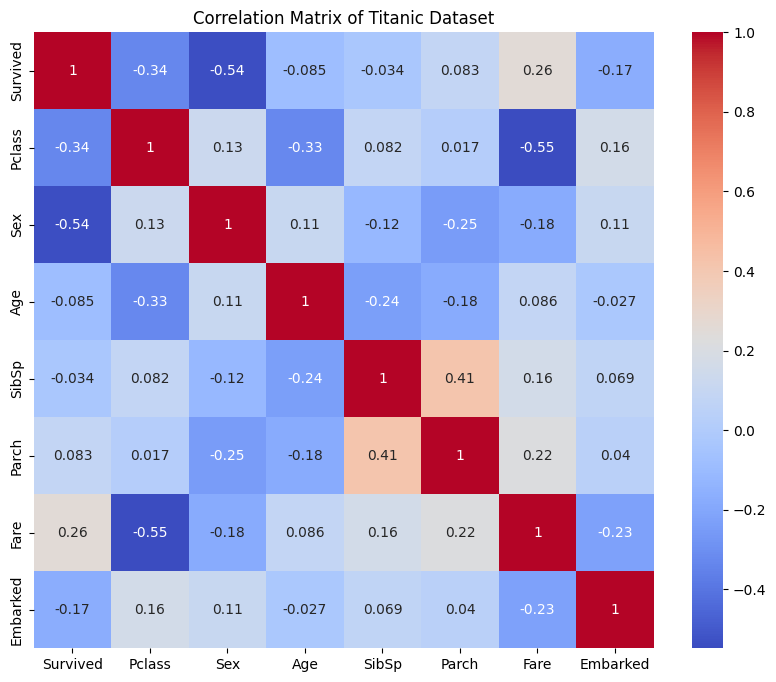

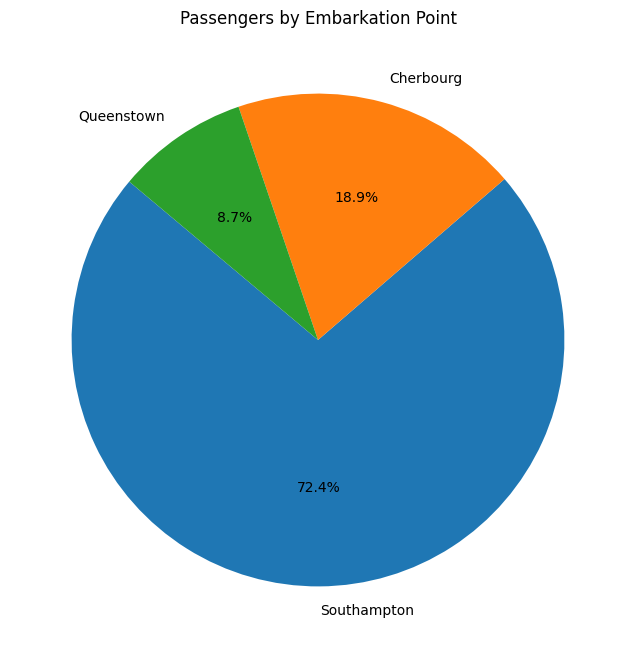

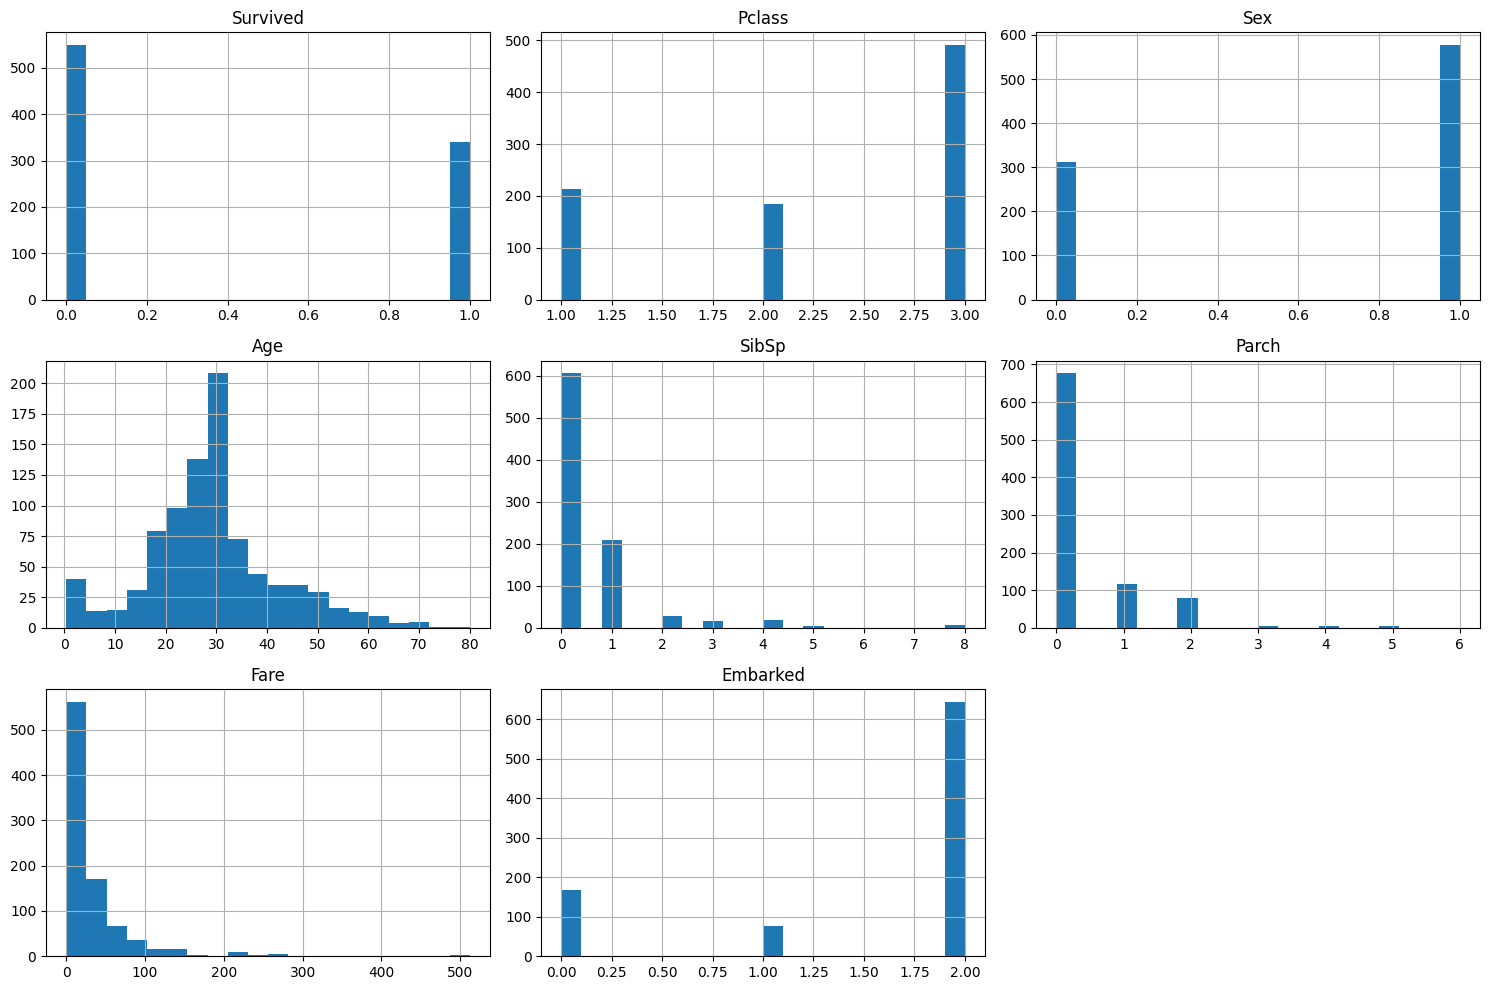

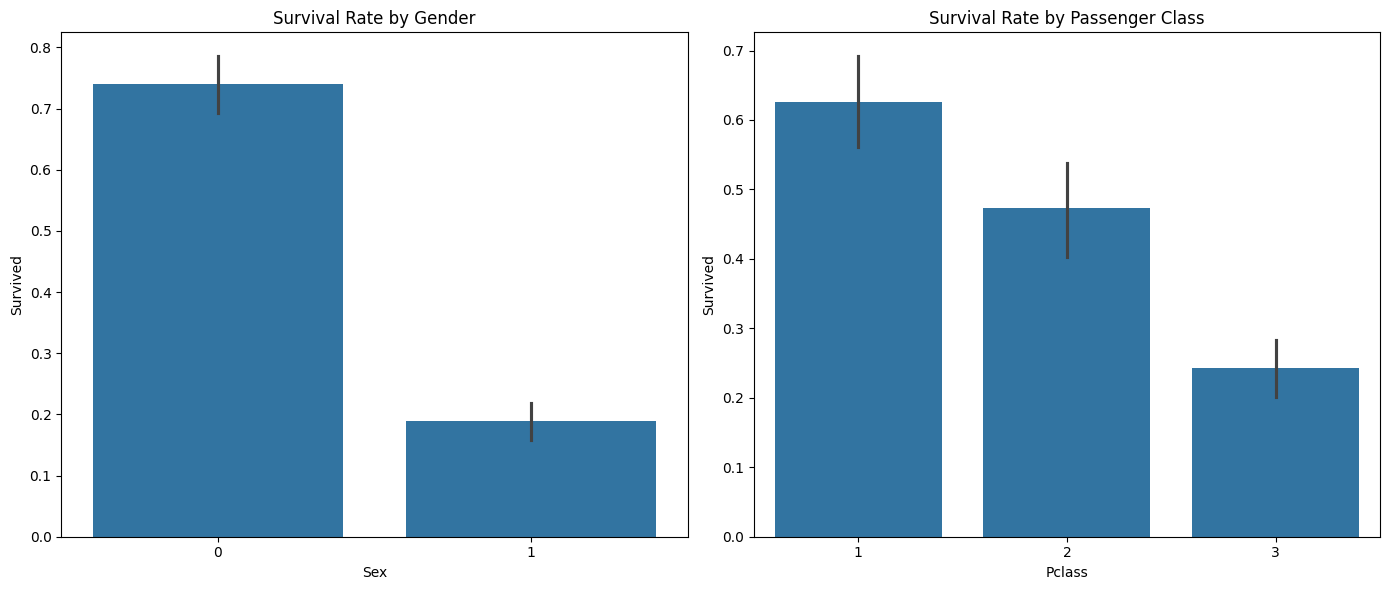

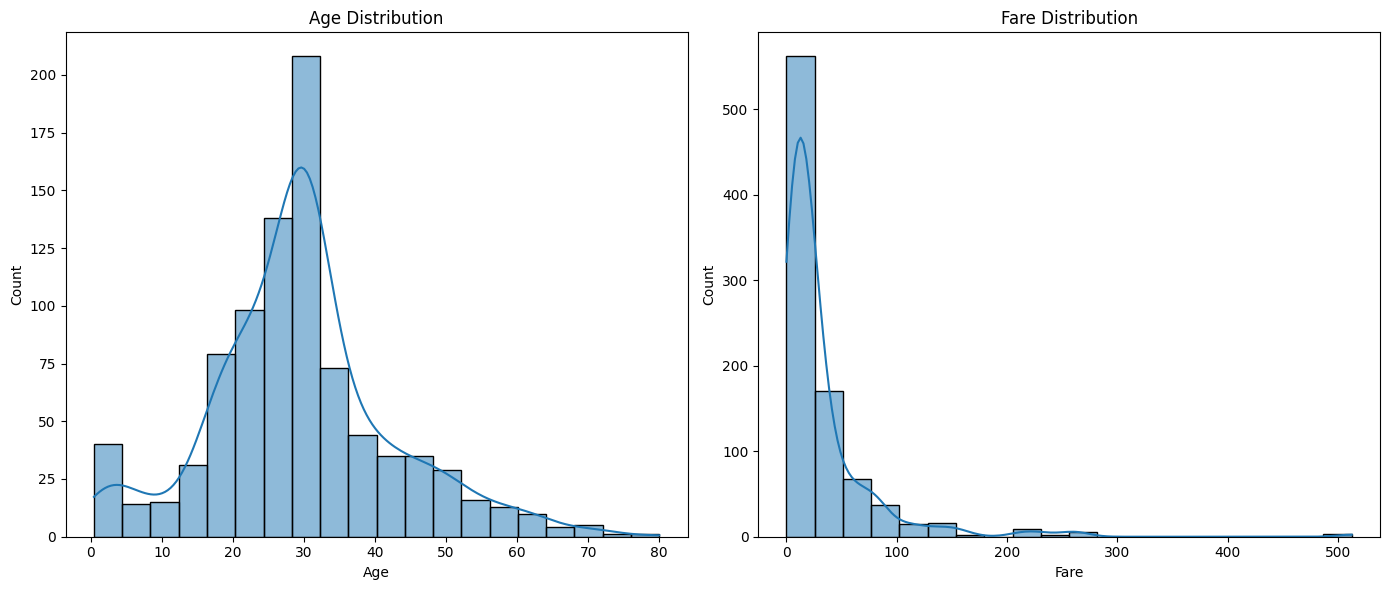

In [4]:


# Drop 'Name' and 'PassengerId' columns
titanic_data = titanic_data.drop(columns=['Name', 'Ticket', 'PassengerId'])

label_encoder = LabelEncoder()
titanic_data['Sex'] = label_encoder.fit_transform(titanic_data['Sex'])
titanic_data['Embarked'] = label_encoder.fit_transform(titanic_data['Embarked'])


# 1. Correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = titanic_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Titanic Dataset')
plt.show()

# 2. Pie plot
embarkation_counts = titanic_data['Embarked'].value_counts()
labels = ['Southampton', 'Cherbourg', 'Queenstown']

plt.figure(figsize=(8, 8))
plt.pie(embarkation_counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Passengers by Embarkation Point')
plt.show()

# 3. Histograms of columns
titanic_data.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

# 4. Survival rates by gender and class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='Sex', y='Survived', data=titanic_data, ax=axes[0])
axes[0].set_title('Survival Rate by Gender')

sns.barplot(x='Pclass', y='Survived', data=titanic_data, ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')

plt.tight_layout()
plt.show()

# 5. Distribution of age and fare
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(titanic_data['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(titanic_data['Fare'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

# Proceed to step 5 after reviewing these visualizations.


### Válasszuk ki a feature és target változónkat, majd split-eljük fel az adathalmazd 25% teszt és 75% train adathalmazra.

In [5]:

# Features and target variable
X = titanic_data.drop('Survived', axis=1) # all columns except 'Survived'
y = titanic_data['Survived'] # target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Checking the shapes of the splits
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


((711, 7), (178, 7), (711,), (178,))

### Taníts fel egy logisztikus regressziót majd értékeld ki a modelled

In [6]:
# Initialize the logistic regression model
log_reg = LogisticRegression(max_iter=1000)

# Fit the model to the training data
log_reg.fit(X_train, y_train)

# Predictions on the test set
y_pred = log_reg.predict(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print(f'Accuracy: {accuracy}')
print(f'Confusion matrix:\n {conf_matrix}')
print(f'Class report: \n{class_report}')

Accuracy: 0.7865168539325843
Confusion matrix:
 [[86 23]
 [15 54]]
Class report: 
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       109
           1       0.70      0.78      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.79      0.79      0.79       178

